Loading FINAL cost surface from c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\final_resistance_surface.tif...
Cost matrix loaded. Shape: 3849x4664
Creating a node grid with 300-pixel spacing...
Total nodes created: 208
Valid (reachable) nodes: 101
Calculating all-pairs paths between 101 nodes...


Processing Node Pairs:   0%|          | 0/101 [00:00<?, ?it/s]

Path accumulation complete.
Plotting results...
Maximum crossings on a single pixel: 1596
Using logarithmic scale for plotting.


C:\Users\Lukas\AppData\Local\Temp\ipykernel_16252\934049292.py:128: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn').copy()


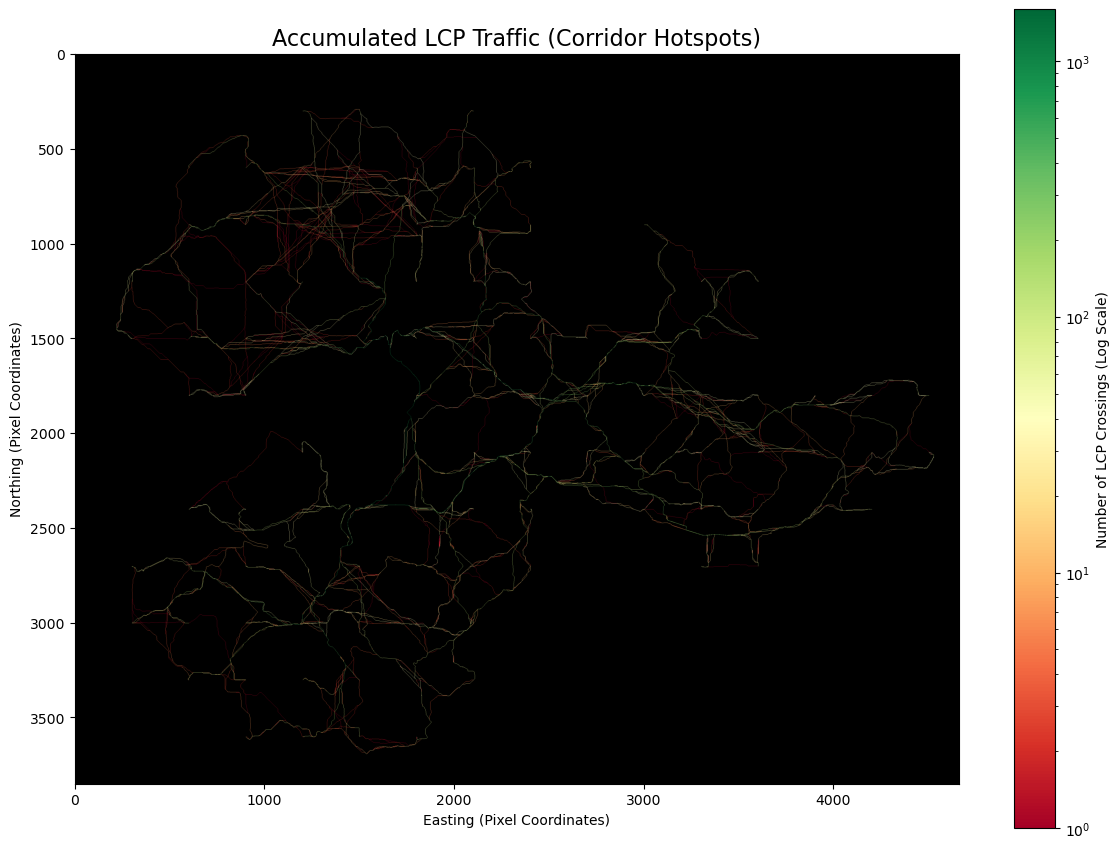

Saving traffic raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\corridor_traffic_grid.tif...
Analysis and plotting complete.


In [28]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from skimage.graph import route_through_array
import os
from tqdm.notebook import tqdm # For a progress bar


BASE_DIR = os.path.abspath('../..') # Gets the current directory of the notebook
RESULTS_DIR = os.path.join(BASE_DIR, "Results")


# --- 1. Define Paths and Settings ---
FINAL_RASTER = os.path.join(RESULTS_DIR, "final_resistance_surface.tif")
GRID_SPACING_METERS = 3000  # 3km grid, as you suggested
EXTREME_BARRIER_COST = 1000  # A very high cost



# --- 2. Load Final Resistance Raster ---
print(f"Loading FINAL cost surface from {FINAL_RASTER}...")
with rasterio.open(FINAL_RASTER) as src:
    resistance_array = src.read(1)
    meta = src.meta.copy()
    nodata_val = meta['nodata']
    

    # Get resolution from metadata
    resolution = meta['transform'][0] 
    

    # Convert NoData to an extreme barrier cost
    resistance_array[resistance_array == nodata_val] = EXTREME_BARRIER_COST

    # Ensure no costs are zero or negative
    resistance_array[resistance_array <= 0] = 1 

    
    # Get the total height and width of the raster in pixels
    height, width = resistance_array.shape


print(f"Cost matrix loaded. Shape: {height}x{width}")


# --- 3. Create the Structured Grid of Nodes ---
# Convert 10,000m spacing to pixel spacing
spacing_pixels = int(GRID_SPACING_METERS / resolution)
print(f"Creating a node grid with {spacing_pixels}-pixel spacing...")


# Create arrays of all row and column indices
rows = np.arange(0, height, spacing_pixels)
cols = np.arange(0, width, spacing_pixels)


# Use meshgrid to create a coordinate pair for each grid point
xx, yy = np.meshgrid(cols, rows)


# Flatten the arrays and zip them into (row, col) tuples
all_grid_nodes = list(zip(yy.ravel(), xx.ravel()))


# --- 4. Filter Nodes ---
# We must remove nodes that fall on "NoData" (now EXTREME_BARRIER_COST) areas
valid_grid_nodes = [
    (r, c) for r, c in all_grid_nodes 
    if resistance_array[r, c] < EXTREME_BARRIER_COST
]


print(f"Total nodes created: {len(all_grid_nodes)}")
print(f"Valid (reachable) nodes: {len(valid_grid_nodes)}")


# --- 5. All-Pairs Path Calculation (The Corrected Logic) ---
print(f"Calculating all-pairs paths between {len(valid_grid_nodes)} nodes...")
# This array will store our "traffic" counts
traffic_array = np.zeros(resistance_array.shape, dtype=np.int32)


# We use tqdm to show a progress bar, as this will take some time
for i in tqdm(range(len(valid_grid_nodes)), desc="Processing Node Pairs"):
    # This inner loop ensures we only calculate each pair *once* (e.g., A->B, not B->A)
    for j in range(i + 1, len(valid_grid_nodes)):
        

        start_node = valid_grid_nodes[i] # (row, col)
        end_node = valid_grid_nodes[j]   # (row, col)

        
        try:
            # Calculate the single path between these two specific nodes
            indices, cost = route_through_array(
                resistance_array,
                start=start_node,
                end=end_node,
                fully_connected=True, # Allows 8-direction movement
                geometric=True      # Corrects for diagonal distance
            )

            
            # Add this path to our traffic map
            if indices:
                rows, cols = zip(*indices)
                traffic_array[rows, cols] += 1

                
        except Exception as e:
            # This can still fail if a node is truly on an 'island'
            # print(f"Could not find path between {start_node} and {end_node}: {e}")
            continue # Skip this pair


print("Path accumulation complete.")


# --- 6. Plot and Save the Final Traffic Map ---
print("Plotting results...")
traffic_masked = np.ma.masked_equal(traffic_array, 0)
max_crossings = traffic_array.max()
print(f"Maximum crossings on a single pixel: {max_crossings}")


fig, ax = plt.subplots(figsize=(12, 12))
cmap = plt.cm.get_cmap('RdYlGn').copy()
cmap.set_bad(color='black') # Color for 0-traffic pixels


# Use robust plotting logic to avoid the LogNorm error
if max_crossings == 0:
    print("ANALYSIS RESULT: No paths were accumulated.")
    im = ax.imshow(traffic_masked, cmap=cmap)
   

elif max_crossings == 1:
    print("Warning: Max crossings is 1. Switching to a linear scale.")
    norm = colors.Normalize(vmin=1, vmax=1)
    im = ax.imshow(traffic_masked, cmap=cmap, norm=norm)
    cbar = fig.colorbar(im, ax=ax, shrink=0.7, ticks=[1])
    cbar.set_label('Number of LCP Crossings (Linear Scale)')
    

else:
    print("Using logarithmic scale for plotting.")
    norm = colors.LogNorm(vmin=1, vmax=max_crossings)
    im = ax.imshow(traffic_masked, cmap=cmap, norm=norm)
    cbar = fig.colorbar(im, ax=ax, shrink=0.7)
    cbar.set_label('Number of LCP Crossings (Log Scale)')


ax.set_title("Accumulated LCP Traffic (Corridor Hotspots)", fontsize=16)
ax.set_xlabel('Easting (Pixel Coordinates)')
ax.set_ylabel('Northing (Pixel Coordinates)')
plt.tight_layout()


# Save the plot image
PLOT_FILE_OUT = os.path.join(RESULTS_DIR, "corridor_traffic_map_grid.png")
plt.savefig(PLOT_FILE_OUT, dpi=300)
plt.show()


# Save the data as a GeoTIFF
traffic_meta = meta.copy()
traffic_meta.update(dtype='int32', nodata=0)
TRAFFIC_RASTER_OUT = os.path.join(RESULTS_DIR, "corridor_traffic_grid.tif")


print(f"Saving traffic raster to {TRAFFIC_RASTER_OUT}...")
with rasterio.open(TRAFFIC_RASTER_OUT, 'w', **traffic_meta) as dest:
    dest.write(traffic_array, 1)


print("Analysis and plotting complete.")

Plotting combined results map with enhanced highlighting...
Plotting faded basemap...


C:\Users\Lukas\AppData\Local\Temp\ipykernel_16252\2771639427.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_base = plt.cm.get_cmap('Blues').copy()


Plotting highlighted traffic overlay...


C:\Users\Lukas\AppData\Local\Temp\ipykernel_16252\2771639427.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_traffic = plt.cm.get_cmap('RdYlGn').copy()


Plotting larger, highlighted nodes...


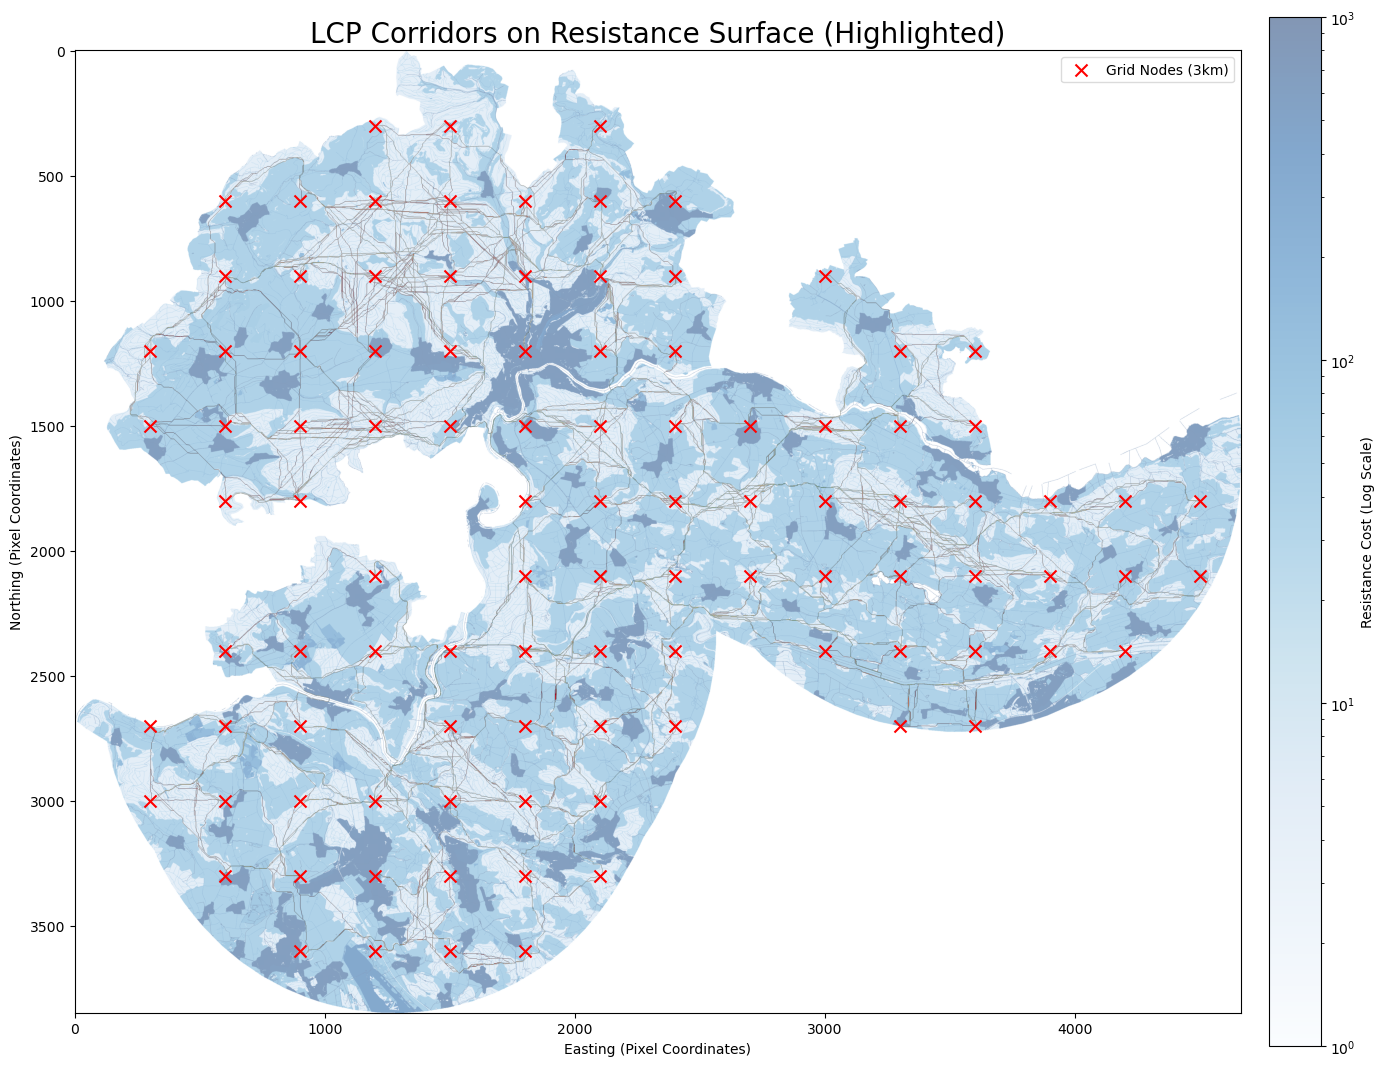

Highlighted composite map saved.


In [29]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os

print("Plotting combined results map with enhanced highlighting...")

# --- 1. Prepare Data for Plotting ---
plot_resistance = resistance_array.copy().astype(float)
plot_resistance[plot_resistance == EXTREME_BARRIER_COST] = np.nan
traffic_masked = np.ma.masked_equal(traffic_array, 0)
max_crossings = traffic_array.max()
node_rows, node_cols = zip(*valid_grid_nodes)

# --- 2. Create the Plot ---
fig, ax = plt.subplots(figsize=(15, 15))

# --- LAYER 1: Plot the Resistance Basemap (Faded) ---
print("Plotting faded basemap...")
cmap_base = plt.cm.get_cmap('Blues').copy()
cmap_base.set_bad(color='white')

im_base = ax.imshow(plot_resistance, 
                    cmap=cmap_base, 
                    norm=colors.LogNorm(vmin=1, vmax=1000),
                    alpha=0.5)  # <-- Added transparency

# Add a colorbar for the resistance
cbar_base = fig.colorbar(im_base, ax=ax, shrink=0.7, pad=0.02, label='Resistance Cost (Log Scale)')

# --- LAYER 2: Plot the Traffic Overlay (Highlighted) ---
print("Plotting highlighted traffic overlay...")
# We use 'cyan' for a bright, high-contrast color
cmap_traffic = plt.cm.get_cmap('RdYlGn').copy()
cmap_traffic.set_bad(color='none') # Make 0-traffic pixels TRANSPARENT

# Use the same robust normalization logic
if max_crossings == 0:
    print("No traffic to plot.")
    
elif max_crossings == 1:
    norm_traffic = colors.Normalize(vmin=1, vmax=1)
    im_traffic = ax.imshow(traffic_masked, cmap=cmap_traffic, norm=norm_traffic)
    
else:
    norm_traffic = colors.LogNorm(vmin=1, vmax=max_crossings)
    im_traffic = ax.imshow(traffic_masked, cmap=cmap_traffic, norm=norm_traffic)

# --- LAYER 3: Plot the Grid Nodes (Bigger) ---
print("Plotting larger, highlighted nodes...")
ax.scatter(node_cols, node_rows, 
           s=75,            # <-- Increased size
           c='red',         # <-- Changed to bright red
           marker='x',      
           label='Grid Nodes (3km)')

# --- 3. Final Touches ---
ax.set_title("LCP Corridors on Resistance Surface (Highlighted)", fontsize=20)
ax.set_xlabel('Easting (Pixel Coordinates)')
ax.set_ylabel('Northing (Pixel Coordinates)')
ax.legend(loc='upper right', facecolor='white', framealpha=0.7)
plt.tight_layout()

# Save the final composite image
PLOT_FILE_OUT = os.path.join(RESULTS_DIR, "final_composite_map_highlighted.png")
plt.savefig(PLOT_FILE_OUT, dpi=300, bbox_inches='tight')

plt.show()

print("Highlighted composite map saved.")